In [1]:
pip install numpy pandas matplotlib seaborn scikit-learn tensorflow keras pillow


In [7]:
# ==========================
# STEP 1: SETUP
# ==========================
import os
import zipfile
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.applications import VGG16
from tensorflow.keras.applications.vgg16 import preprocess_input
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing import image
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from tensorflow.keras.utils import to_categorical

# ==========================
# STEP 2: UNZIP DATASET
# ==========================
# Assuming you uploaded archive.zip into Colab Files tab
zip_path = "/content/archive (2).zip"
extract_path = "/content/Thyroid Data"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

# Dataset structure:
# dataset/Thyroid Data/0/
# dataset/Thyroid Data/1/

base_dir = os.path.join(extract_path, "Thyroid Data")

# ==========================
# STEP 3: DATA GENERATORS
# ==========================
img_size = (128, 128)
batch_size = 32

datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

train_gen = datagen.flow_from_directory(
    base_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical',
    subset='training'
)

val_gen = datagen.flow_from_directory(
    base_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical',
    subset='validation'
)

# ==========================
# STEP 4: SIMPLE CNN MODEL
# ==========================
cnn_model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(128,128,3)),
    MaxPooling2D(2,2),
    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(2, activation='softmax')
])

cnn_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
history_cnn = cnn_model.fit(train_gen, validation_data=val_gen, epochs=5)

# ==========================
# STEP 5: VGG16 TRANSFER LEARNING
# ==========================
base_vgg = VGG16(weights='imagenet', include_top=False, input_shape=(128,128,3))
for layer in base_vgg.layers:
    layer.trainable = False

x = Flatten()(base_vgg.output)
x = Dense(128, activation='relu')(x)
x = Dropout(0.5)(x)
predictions = Dense(2, activation='softmax')(x)

vgg_model = Model(inputs=base_vgg.input, outputs=predictions)
vgg_model.compile(optimizer=Adam(1e-4), loss='categorical_crossentropy', metrics=['accuracy'])

history_vgg = vgg_model.fit(train_gen, validation_data=val_gen, epochs=5)

# ==========================
# STEP 6: RANDOM FOREST ON FEATURES
# ==========================
# Extract features using VGG16
feature_extractor = Model(inputs=base_vgg.input, outputs=Flatten()(base_vgg.output))

# Get training features
train_features = feature_extractor.predict(train_gen)
train_labels = train_gen.classes

# Get validation features
val_features = feature_extractor.predict(val_gen)
val_labels = val_gen.classes

# Train Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(train_features, train_labels)

rf_preds = rf.predict(val_features)
rf_acc = accuracy_score(val_labels, rf_preds)
print("Random Forest Validation Accuracy:", rf_acc)

# ==========================
# STEP 7: PREDICT ON NEW IMAGE
# ==========================
from google.colab import files

def predict_new_image(model, img_path, model_type="cnn"):
    img = image.load_img(img_path, target_size=(128,128))
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)

    if model_type == "cnn":
        img_array = img_array/255.0
        preds = model.predict(img_array)
    elif model_type == "vgg":
        img_array = preprocess_input(img_array)
        preds = model.predict(img_array)
    else:
        img_array = preprocess_input(img_array)
        features = feature_extractor.predict(img_array)
        preds = rf.predict(features)
        return "Thyroid Detected" if preds[0] == 1 else "No Thyroid"

    class_idx = np.argmax(preds, axis=1)[0]
    return "Thyroid Detected" if class_idx == 1 else "No Thyroid"

# Example: Upload new test image
uploaded = files.upload()
for fn in uploaded.keys():
    result = predict_new_image(vgg_model, fn, model_type="vgg")
    print(f"Prediction for {fn}: {result}")


Found 2492 images belonging to 2 classes.
Found 623 images belonging to 2 classes.


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/5
78/78 ━━━━━━━━━━━━━━━━━━━━ 76s 941ms/step - accuracy: 0.6113 - loss: 0.7515 - val_accuracy: 0.7063 - val_loss: 0.5618
Epoch 2/5
78/78 ━━━━━━━━━━━━━━━━━━━━ 70s 895ms/step - accuracy: 0.6348 - loss: 0.6266 - val_accuracy: 0.6886 - val_loss: 0.5821
Epoch 3/5
78/78 ━━━━━━━━━━━━━━━━━━━━ 71s 905ms/step - accuracy: 0.6947 - loss: 0.5750 - val_accuracy: 0.7127 - val_loss: 0.5613
Epoch 4/5
78/78 ━━━━━━━━━━━━━━━━━━━━ 71s 909ms/step - accuracy: 0.7192 - loss: 0.5239 - val_accuracy: 0.6437 - val_loss: 0.6255
Epoch 5/5
78/78 ━━━━━━━━━━━━━━━━━━━━ 68s 877ms/step - accuracy: 0.8049 - loss: 0.4081 - val_accuracy: 0.5811 - val_loss: 0.6843
58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/5
78/78 ━━━━━━━━━━━━━━━━━━━━ 616s 8s/step - accuracy: 0.5854 - loss: 0.7082 - val_accuracy: 0.6854 - val_loss: 0.6028
Epoch 2/5
78/78 ━━━━━━━━━━━━━━━━━━━━ 630s 8s/step - accuracy: 0.6367 - loss: 0.6059 - val_accuracy: 0.6742 - val_loss: 0.5981
Epoch 3/5
78/78 ━━━━━━━━━━━━━━━━━━━━ 611s 8s/step - accur

Saving 2838.jpg to 2838.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 673ms/step
Prediction for 2838.jpg: No Thyroid


Class mapping will be: ['1', '0']
Found 2492 images belonging to 2 classes.
Found 623 images belonging to 2 classes.
Class indices: {'0': 0, '1': 1}
Epoch 1/10
78/78 ━━━━━━━━━━━━━━━━━━━━ 14s 129ms/step - accuracy: 0.5890 - loss: 4.2712 - val_accuracy: 0.5955 - val_loss: 2.2522
Epoch 2/10
78/78 ━━━━━━━━━━━━━━━━━━━━ 15s 90ms/step - accuracy: 0.7135 - loss: 1.3584 - val_accuracy: 0.6051 - val_loss: 1.4286
Epoch 3/10
78/78 ━━━━━━━━━━━━━━━━━━━━ 7s 96ms/step - accuracy: 0.7790 - loss: 0.6655 - val_accuracy: 0.6404 - val_loss: 1.2317
Epoch 4/10
78/78 ━━━━━━━━━━━━━━━━━━━━ 8s 106ms/step - accuracy: 0.8272 - loss: 0.4059 - val_accuracy: 0.6180 - val_loss: 1.2482
Epoch 5/10
78/78 ━━━━━━━━━━━━━━━━━━━━ 7s 91ms/step - accuracy: 0.8704 - loss: 0.3193 - val_accuracy: 0.5875 - val_loss: 1.2462
Epoch 6/10
78/78 ━━━━━━━━━━━━━━━━━━━━ 8s 96ms/step - accuracy: 0.9178 - loss: 0.2006 - val_accuracy: 0.5891 - val_loss: 1.3349
Epoch 7/10
78/78 ━━━━━━━━━━━━━━━━━━━━ 7s 89ms/step - accuracy: 0.9221 - loss: 0.1967 

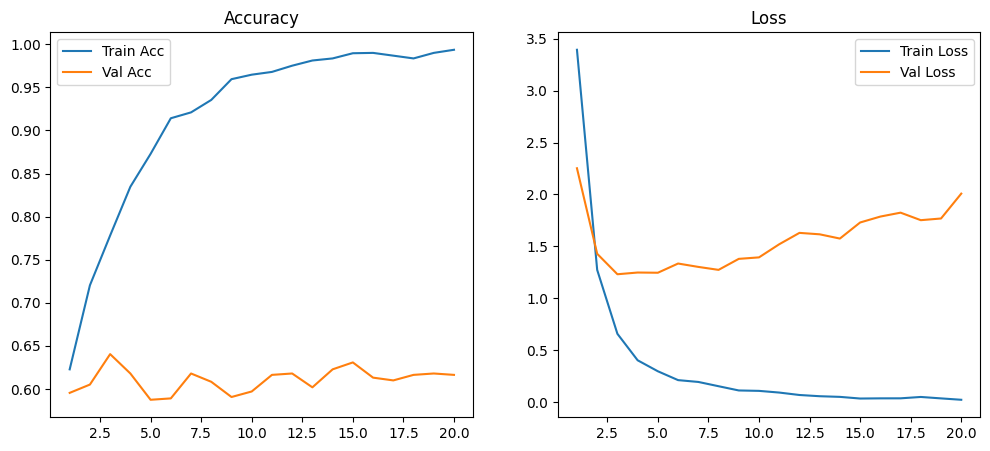

In [5]:
# ==========================
# STEP 1: SETUP
# ==========================
import os
import zipfile
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import VGG16
from tensorflow.keras.applications.vgg16 import preprocess_input
from tensorflow.keras.layers import Flatten, Dense, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing import image
from google.colab import files

# ==========================
# STEP 2: UNZIP DATASET
# ==========================
zip_path = "/content/archive (2).zip"
extract_path = "/content/Thyroid Data"


with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

base_dir = os.path.join(extract_path, "Thyroid Data")

# Check label mapping
print("Class mapping will be:", os.listdir(base_dir))

# ==========================
# STEP 3: DATA GENERATORS
# ==========================
img_size = (128, 128)
batch_size = 32

train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    validation_split=0.2
)

train_gen = train_datagen.flow_from_directory(
    base_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical',
    subset='training'
)

val_gen = train_datagen.flow_from_directory(
    base_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical',
    subset='validation'
)

print("Class indices:", train_gen.class_indices)  # {'0':0, '1':1}

# ==========================
# STEP 4: BUILD VGG16 MODEL
# ==========================
base_vgg = VGG16(weights='imagenet', include_top=False, input_shape=(128,128,3))

# Freeze all layers first
for layer in base_vgg.layers:
    layer.trainable = False

x = Flatten()(base_vgg.output)
x = Dense(256, activation='relu')(x)
x = Dropout(0.5)(x)
output = Dense(2, activation='softmax')(x)

vgg_model = Model(inputs=base_vgg.input, outputs=output)
vgg_model.compile(optimizer=Adam(1e-4), loss='categorical_crossentropy', metrics=['accuracy'])

# ==========================
# STEP 5: TRAIN (frozen layers)
# ==========================
history = vgg_model.fit(train_gen, validation_data=val_gen, epochs=10)

# ==========================
# STEP 6: FINE-TUNE (unfreeze last 4 conv layers)
# ==========================
for layer in base_vgg.layers[-4:]:
    layer.trainable = True

vgg_model.compile(optimizer=Adam(1e-5), loss='categorical_crossentropy', metrics=['accuracy'])
history_ft = vgg_model.fit(train_gen, validation_data=val_gen, epochs=10)

# ==========================
# STEP 7: PLOT TRAINING CURVES
# ==========================
def plot_history(h1, h2):
    acc = h1.history['accuracy'] + h2.history['accuracy']
    val_acc = h1.history['val_accuracy'] + h2.history['val_accuracy']
    loss = h1.history['loss'] + h2.history['loss']
    val_loss = h1.history['val_loss'] + h2.history['val_loss']

    epochs = range(1, len(acc)+1)
    plt.figure(figsize=(12,5))
    plt.subplot(1,2,1)
    plt.plot(epochs, acc, label="Train Acc")
    plt.plot(epochs, val_acc, label="Val Acc")
    plt.legend()
    plt.title("Accuracy")

    plt.subplot(1,2,2)
    plt.plot(epochs, loss, label="Train Loss")
    plt.plot(epochs, val_loss, label="Val Loss")
    plt.legend()
    plt.title("Loss")
    plt.show()

plot_history(history, history_ft)

# ==========================
# STEP 8: PREDICT ON NEW IMAGE
# ==========================
def predict_new_image(img_path):
    img = image.load_img(img_path, target_size=(128,128))
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)
    img_array = preprocess_input(img_array)

    preds = vgg_model.predict(img_array)
    class_idx = np.argmax(preds, axis=1)[0]

    mapping = {v:k for k,v in train_gen.class_indices.items()}
    predicted_class = mapping[class_idx]

    return "Thyroid Detected" if predicted_class == "1" else "No Thyroid"




In [9]:
# Example: Upload new test image
uploaded = files.upload()
for fn in uploaded.keys():
    result = predict_new_image(fn)
    print(f"Prediction for {fn}: {result}")

Saving 2617.jpg to 2617.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
Prediction for 2617.jpg: No Thyroid
